In [1]:
import nonlinear_benchmarks as nlb
from matplotlib import pyplot as plt
import numpy as np

In [2]:
train_val, test = nlb.WienerHammerBenchMark()
print(train_val) 
# prints : Input_output_data "train WH" u.shape=(100000,) y.shape=(100000,) sampling_time=1.953e-05
print(test)
# prints: Input_output_data "test WH" u.shape=(78800,) y.shape=(78800,) sampling_time=1.953e-05 state_initialization_window_length=50
sampling_time = train_val.sampling_time #in seconds
u_train, y_train = train_val  #or train_val.u, train_val.y
u_test, y_test = test         #or test.u,      test.y
print(test.state_initialization_window_length) #the number of samples that can be used at the start of the test set to initialize the model state.

Input_output_data "train WH" u.shape=(100000,) y.shape=(100000,) sampling_time=1.953e-05
Input_output_data "test WH" u.shape=(78800,) y.shape=(78800,) sampling_time=1.953e-05 state_initialization_window_length=50
50


## EMPS

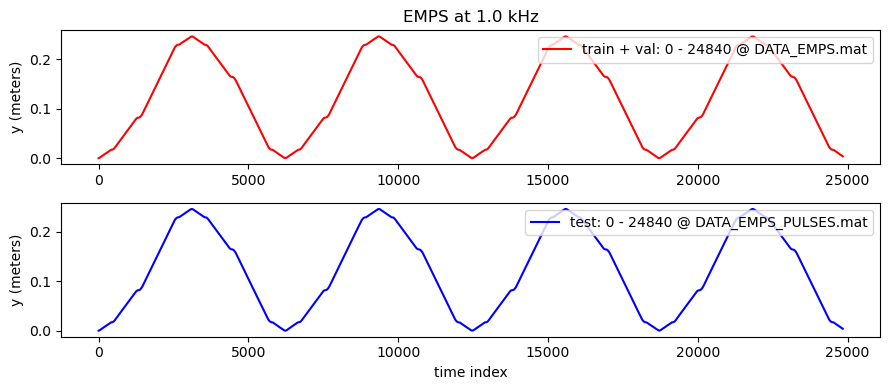

In [3]:
train_val, test = nlb.EMPS(train_test_split=True)
train_val_u, train_val_y = train_val
test_u, test_y = test

plt.figure(figsize=(9,4))
plt.subplot(2,1,1)
plt.title(f'EMPS at {1/train_val.sampling_time/1000:.1f} kHz')
plt.plot(train_val.y,'r',label=f'train + val: 0 - {len(train_val)-1} @ DATA_EMPS.mat')
plt.legend(loc='upper right')
plt.ylabel('y (meters)')
plt.subplot(2,1,2)
plt.plot(test.y,'b',label=f'test: 0 - {len(test)-1} @ DATA_EMPS_PULSES.mat')
plt.legend(loc='upper right')
plt.xlabel('time index')
plt.ylabel('y (meters)')
plt.tight_layout()
plt.savefig('../figures/EMPS.jpg',dpi=300)
plt.show()

### CED

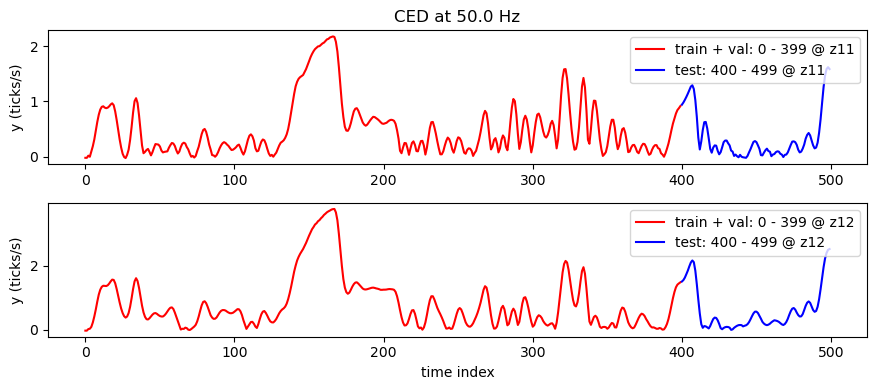

In [4]:
train_val, test = nlb.CED()
(train_val_u_1, train_val_y_1), (train_val_u_2, train_val_y_2) = train_val
(test_u_1, test_y_1), (test_u_2, test_y_2) = test

plt.figure(figsize=(9,4))
plt.subplot(2,1,1)
plt.title(f'CED at {1/train_val[0].sampling_time} Hz')
plt.plot(np.arange(400),train_val[0].y,'r',label='train + val: 0 - 399 @ z11')
plt.plot(np.arange(400,500),test[0].y,'b',label='test: 400 - 499 @ z11')
plt.ylabel('y (ticks/s)')
plt.legend(loc='upper right')
plt.subplot(2,1,2)
plt.plot(np.arange(400),train_val[1].y,'r',label='train + val: 0 - 399 @ z12')
plt.plot(np.arange(400,500),test[1].y,'b',label='test: 400 - 499 @ z12')
plt.ylabel('y (ticks/s)')
plt.legend(loc='upper right')
plt.xlabel('time index')
plt.tight_layout()
plt.savefig('../figures/CED.jpg',dpi=300)
plt.show()

## Cascaded_Tanks

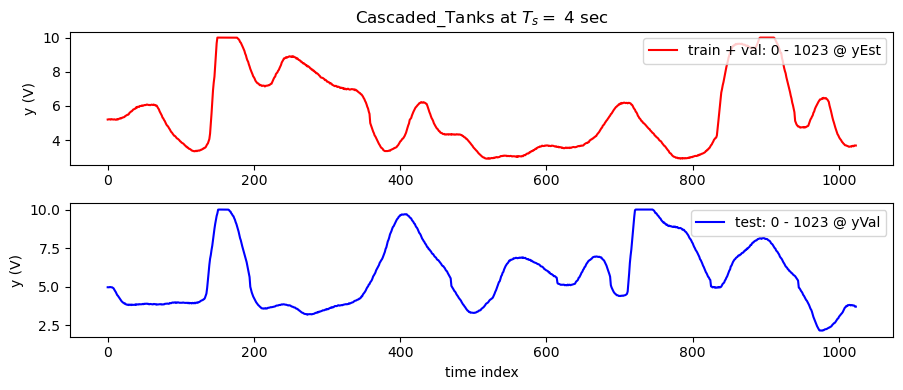

In [5]:
train_val, test = nlb.Cascaded_Tanks()
train_val_u, train_val_y = train_val
test_u, test_y = test

plt.figure(figsize=(9,4))
plt.subplot(2,1,1)
plt.title(f'Cascaded_Tanks at $T_s=$ {train_val.sampling_time} sec')
plt.plot(train_val.y,'r',label=f'train + val: 0 - {len(train_val)-1} @ yEst')
plt.ylabel('y (V)')
plt.legend(loc='upper right')
plt.subplot(2,1,2)
plt.plot(test.y,'b',label=f'test: {0} - {len(test)-1} @ yVal')
plt.ylabel('y (V)')
plt.legend(loc='upper right')
plt.xlabel('time index')
plt.tight_layout()
plt.savefig('../figures/Cascaded_Tanks.jpg',dpi=300)
plt.show()

## WienerHammerBenchMark

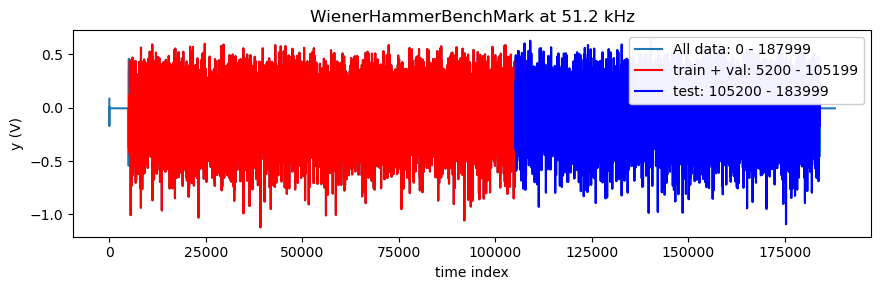

In [6]:
train_val, test = nlb.WienerHammerBenchMark()
train_val_u, train_val_y = train_val
test_u, test_y = test

full = nlb.WienerHammerBenchMark(train_test_split=False)

plt.figure(figsize=(9,3))
plt.plot(full.y,label=f'All data: 0 - {len(full)-1}')
plt.title(f'WienerHammerBenchMark at {1/train_val.sampling_time/1000:.1f} kHz')

L, R = 5200, 5200 + 100000
plt.plot(np.arange(L,R),train_val.y,'r', label=f'train + val: {L} - {R-1}')
L, R = R, R + len(test)
plt.plot(np.arange(L,R),test.y,'b', label=f'test: {L} - {R-1}')
plt.ylabel('y (V)')
plt.legend(loc='upper right',framealpha=0.95)
plt.xlabel('time index')
plt.tight_layout()
plt.savefig('../figures/WienerHammerBenchMark.jpg',dpi=300)
plt.show()

## Silverbox

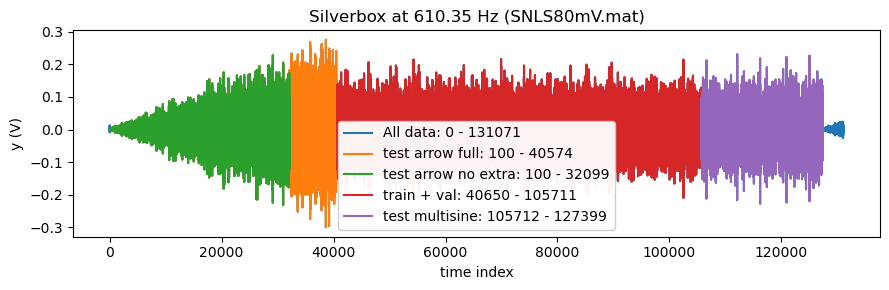

In [7]:
full = nlb.Silverbox(train_test_split=False)

train_val, test = nlb.Silverbox()
multisine_train_val = train_val
test_multisine, test_arrow_full, test_arrow_no_extrapolation = test

plt.figure(figsize=(9,3))
plt.plot(full.y,label=f'All data: 0 - {len(full)-1}')
plt.title(f'Silverbox at {1/train_val.sampling_time} Hz (SNLS80mV.mat)')

L, R = 100, 40575
plt.plot(np.arange(L,R),test_arrow_full.y, label=f'test arrow full: {L} - {R-1}')
L, R = 100, 100+32000
plt.plot(np.arange(L,R),test_arrow_no_extrapolation.y, label=f'test arrow no extra: {L} - {R-1}')
L, R = 40650, 40650 + len(multisine_train_val)
plt.plot(np.arange(L,R),multisine_train_val.y, label=f'train + val: {L} - {R-1}')
L, R = 40650 + len(multisine_train_val), 40650 + len(multisine_train_val) + len(test_multisine)
plt.plot(np.arange(L,R),test_multisine.y, label=f'test multisine: {L} - {R-1}')
plt.ylabel('y (V)')
plt.legend(loc='lower center',framealpha=0.95)
plt.xlabel('time index')
plt.tight_layout()
plt.savefig('../figures/Silverbox.jpg',dpi=300)
plt.show()


## F-16 Ground Vibration Test

https://www.nonlinearbenchmark.org/benchmarks/f-16-gvt

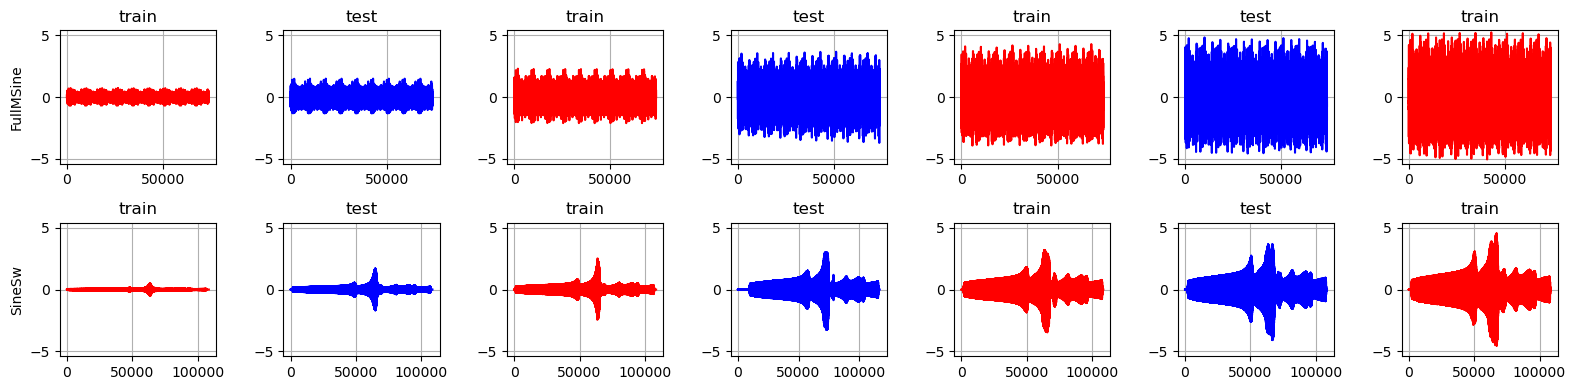

In [8]:
data = nlb.F16(train_test_split=False)
plt.figure(figsize=(16,4))
for i, d in enumerate(data, start=1):
    plt.subplot(2,7,i)
    if i==1:
        plt.ylabel('FullMSine')
    elif i==8:
        plt.ylabel('SineSw')
    plt.title('test' if 'Validation' in d.name else 'train')
    plt.plot(d.y, c='b' if 'Validation' in d.name else 'r')
    plt.ylim(-5.4, 5.4)
    plt.grid()
plt.tight_layout()
plt.savefig('../figures/F16.jpg',dpi=300)
plt.show()

## Parallel Wiener-Hammerstein System

https://www.nonlinearbenchmark.org/benchmarks/parallel-wiener-hammerstein

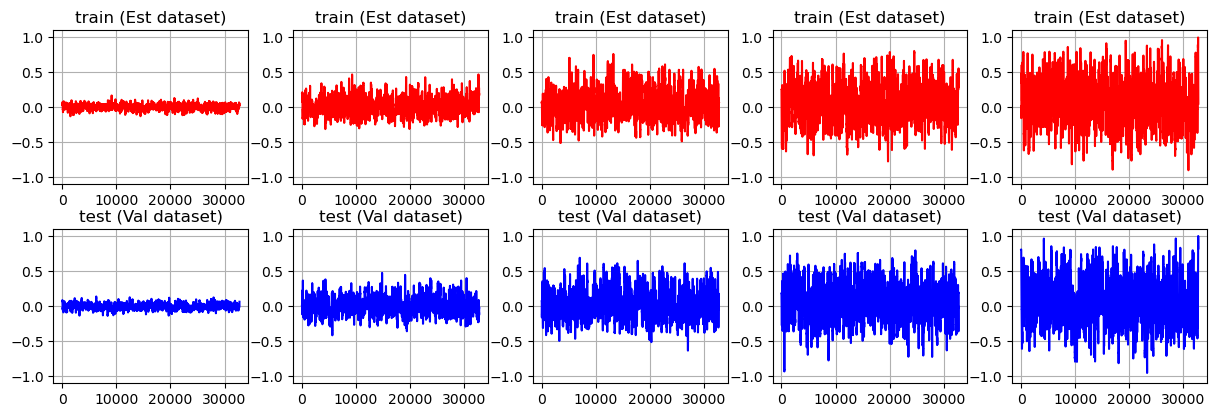

In [9]:
data = nlb.ParWH(train_test_split=False)
plt.figure(figsize=(12,4))
for i,d in enumerate(data[:5], start=1):
    plt.subplot(2,5,i)
    plt.title(f'train (Est dataset)')
    plt.plot(d.y, c='r')
    plt.ylim(-1.1, 1.1)
    plt.grid()
for i,d in enumerate(data[-5:], start=1):
    plt.subplot(2,5,i+5)
    plt.plot(d.y, c='b')
    plt.title(f'test (Val dataset)')
    plt.ylim(-1.1, 1.1)
    plt.grid()
plt.tight_layout(pad=0.1)
plt.savefig('../figures/ParWH.jpg',dpi=300)
plt.show()

## CubeSpec Fine Steering Mirror

https://www.nonlinearbenchmark.org/benchmarks/fine-steering-mirror

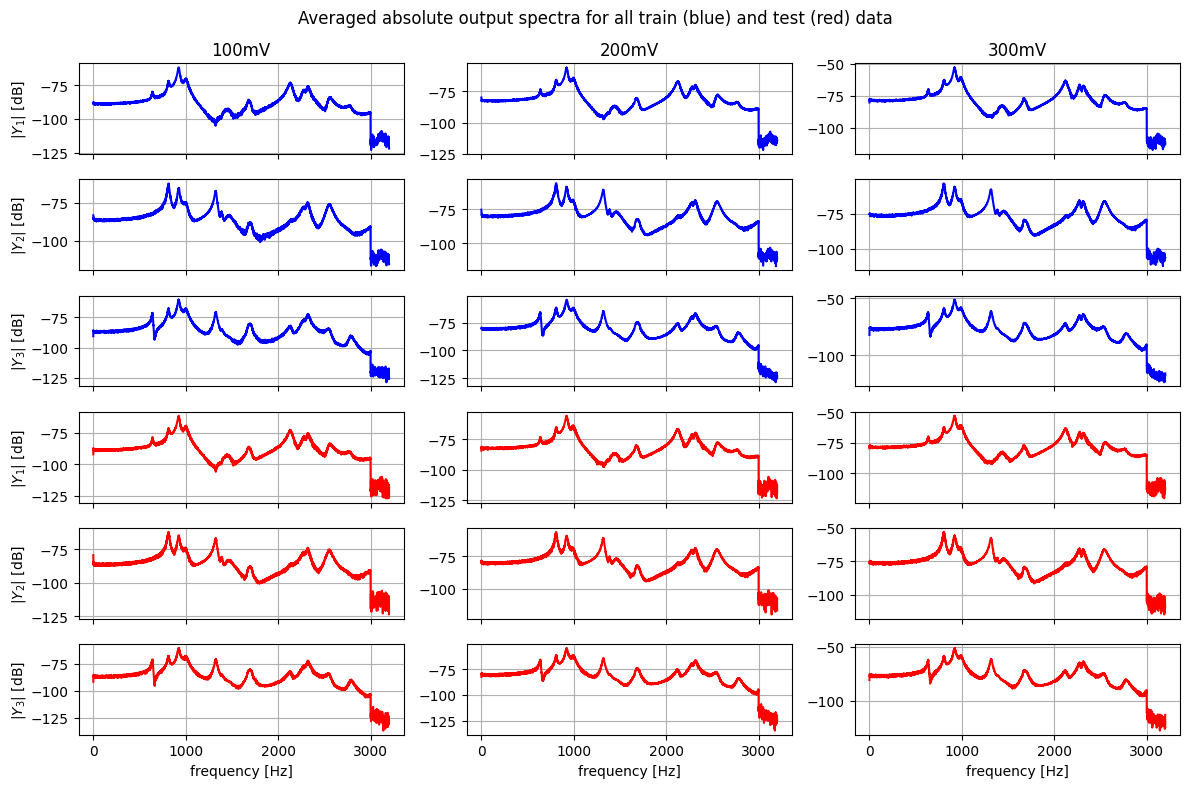

In [3]:
data_train, data_test = nlb.FineSteeringMirror()

amplitude_list = ["100mV", "200mV", "300mV"]
N, ny, fs = 8192, 3, 6400
f = np.arange(N // 2 + 1) * fs / N

fig, axes = plt.subplots(2 * ny, len(amplitude_list), figsize=(12, 8), sharex="col")
fig.suptitle("Averaged absolute output spectra for all train (blue) and test (red) data")
for col_idx, amp in enumerate(amplitude_list):
    axes[0, col_idx].set_title(amp)   
data_dict = {d.name: d for group in (data_train, data_test) for d in group}
for row_offset, split, color in [(0, "train", "b"), (ny, "test", "r")]:
    for output_idx in range(ny):
        spectra = [20 * np.log10(np.mean(np.abs(np.fft.rfft(data_dict[f"{split} {amp}"].y[:, output_idx, :, :], axis=0)), axis=(1, 2))) for amp in amplitude_list]
        for col_idx, spectrum in enumerate(spectra):
            axes[output_idx + row_offset, col_idx].plot(f, spectrum, c=color)
        axes[output_idx + row_offset, 0].set_ylabel(rf"$|Y_{output_idx + 1}|$ [dB]", labelpad=2)
for ax in axes.flat:
    ax.grid(True)
for ax in axes[-1]:
    ax.set_xlabel("frequency [Hz]")

plt.tight_layout()
plt.savefig("../figures/FineSteeringMirror.jpg", dpi=300)
plt.show()

# NanoDrone

https://github.com/idsia-robotics/nanodrone-sysid-benchmark

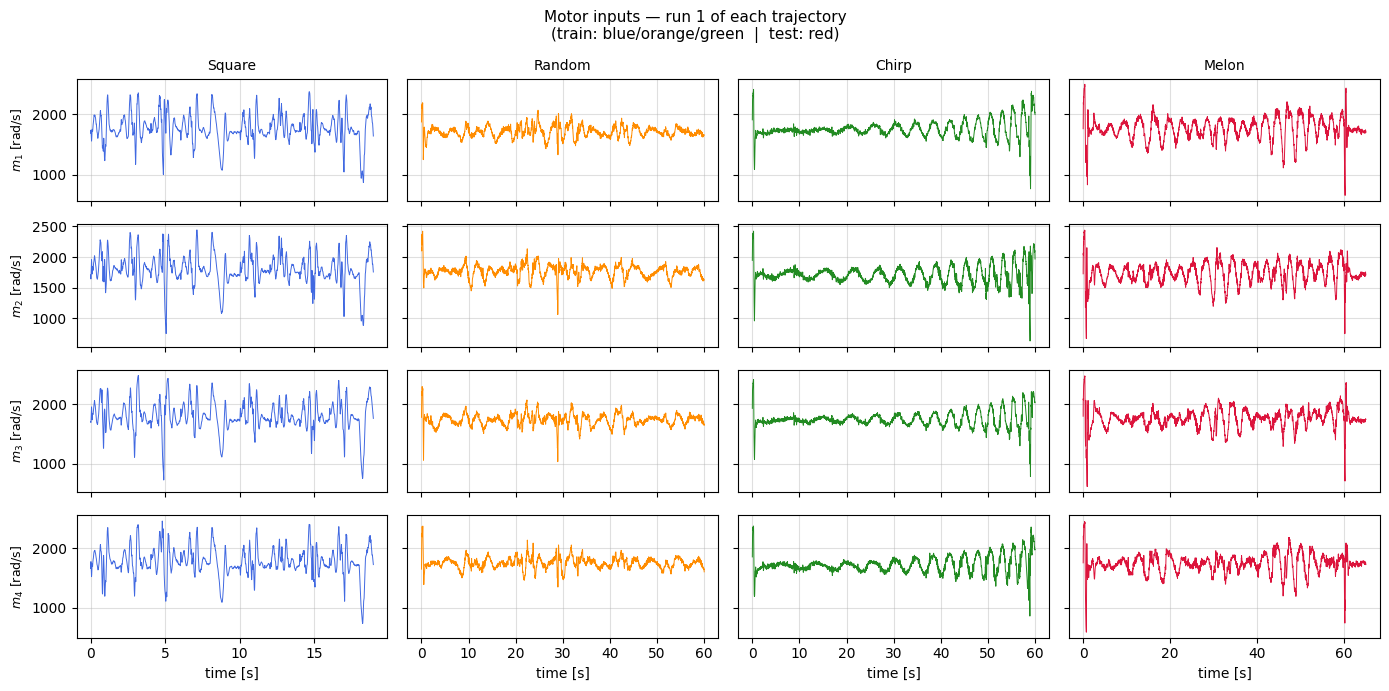

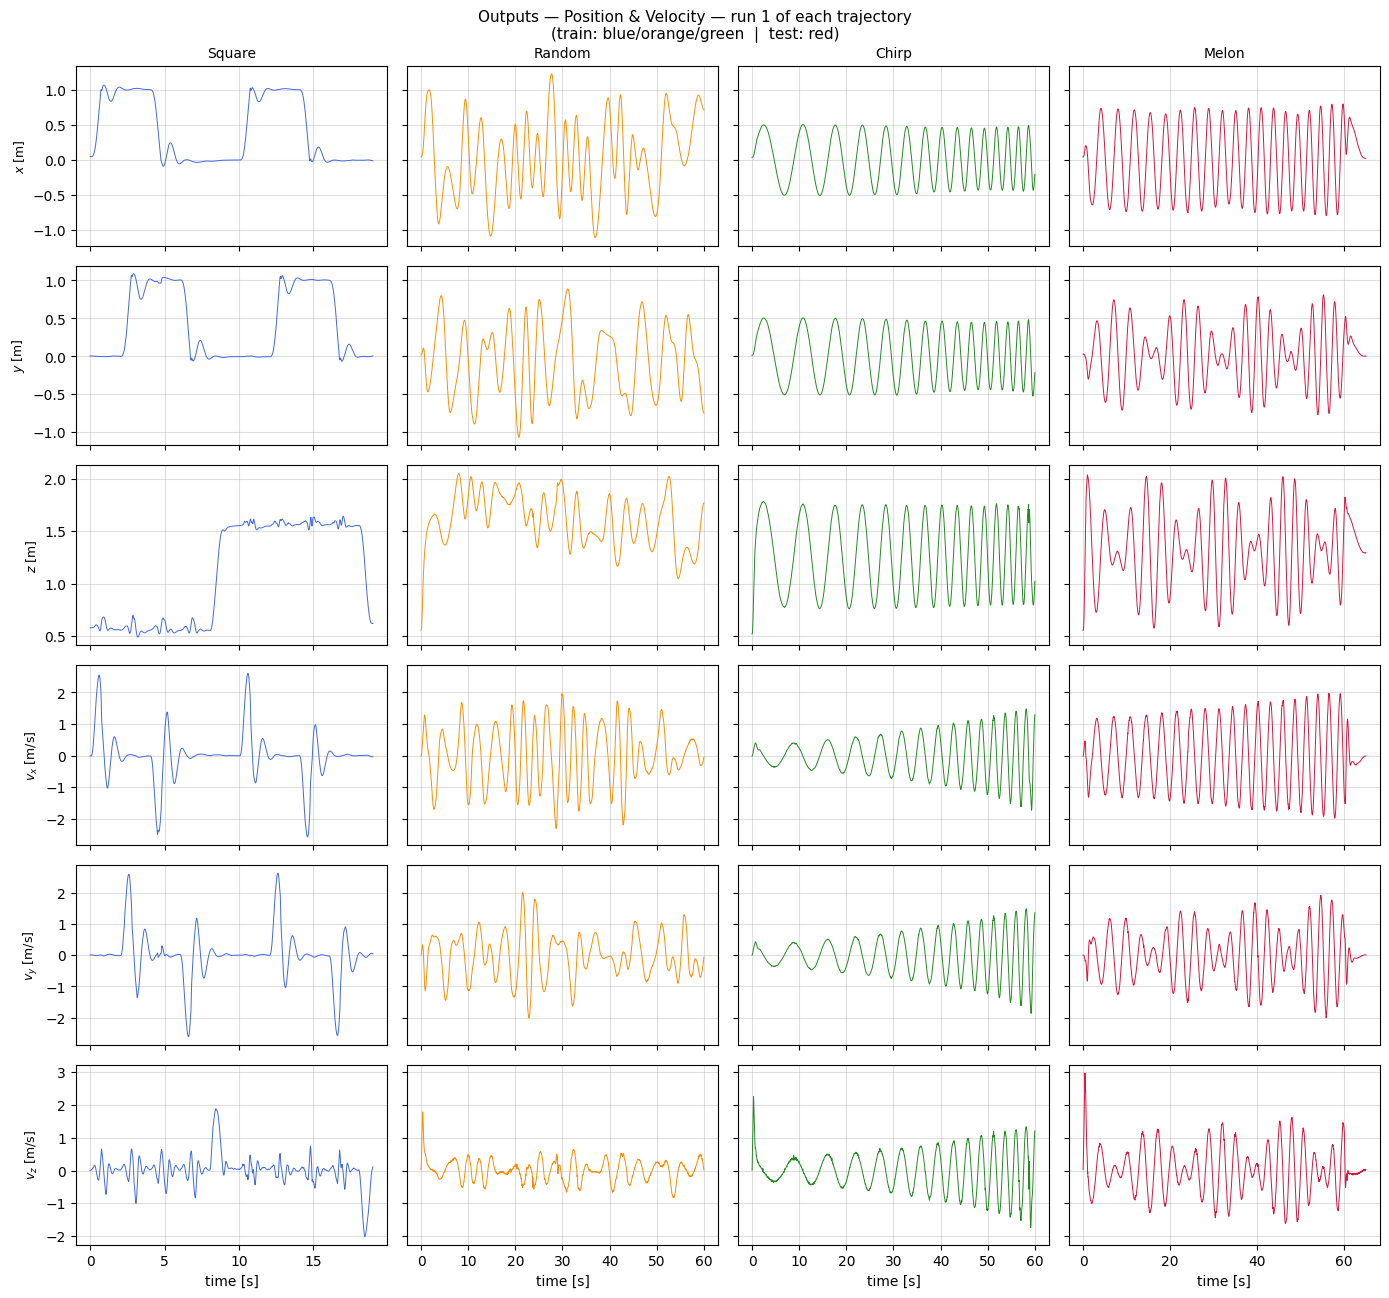

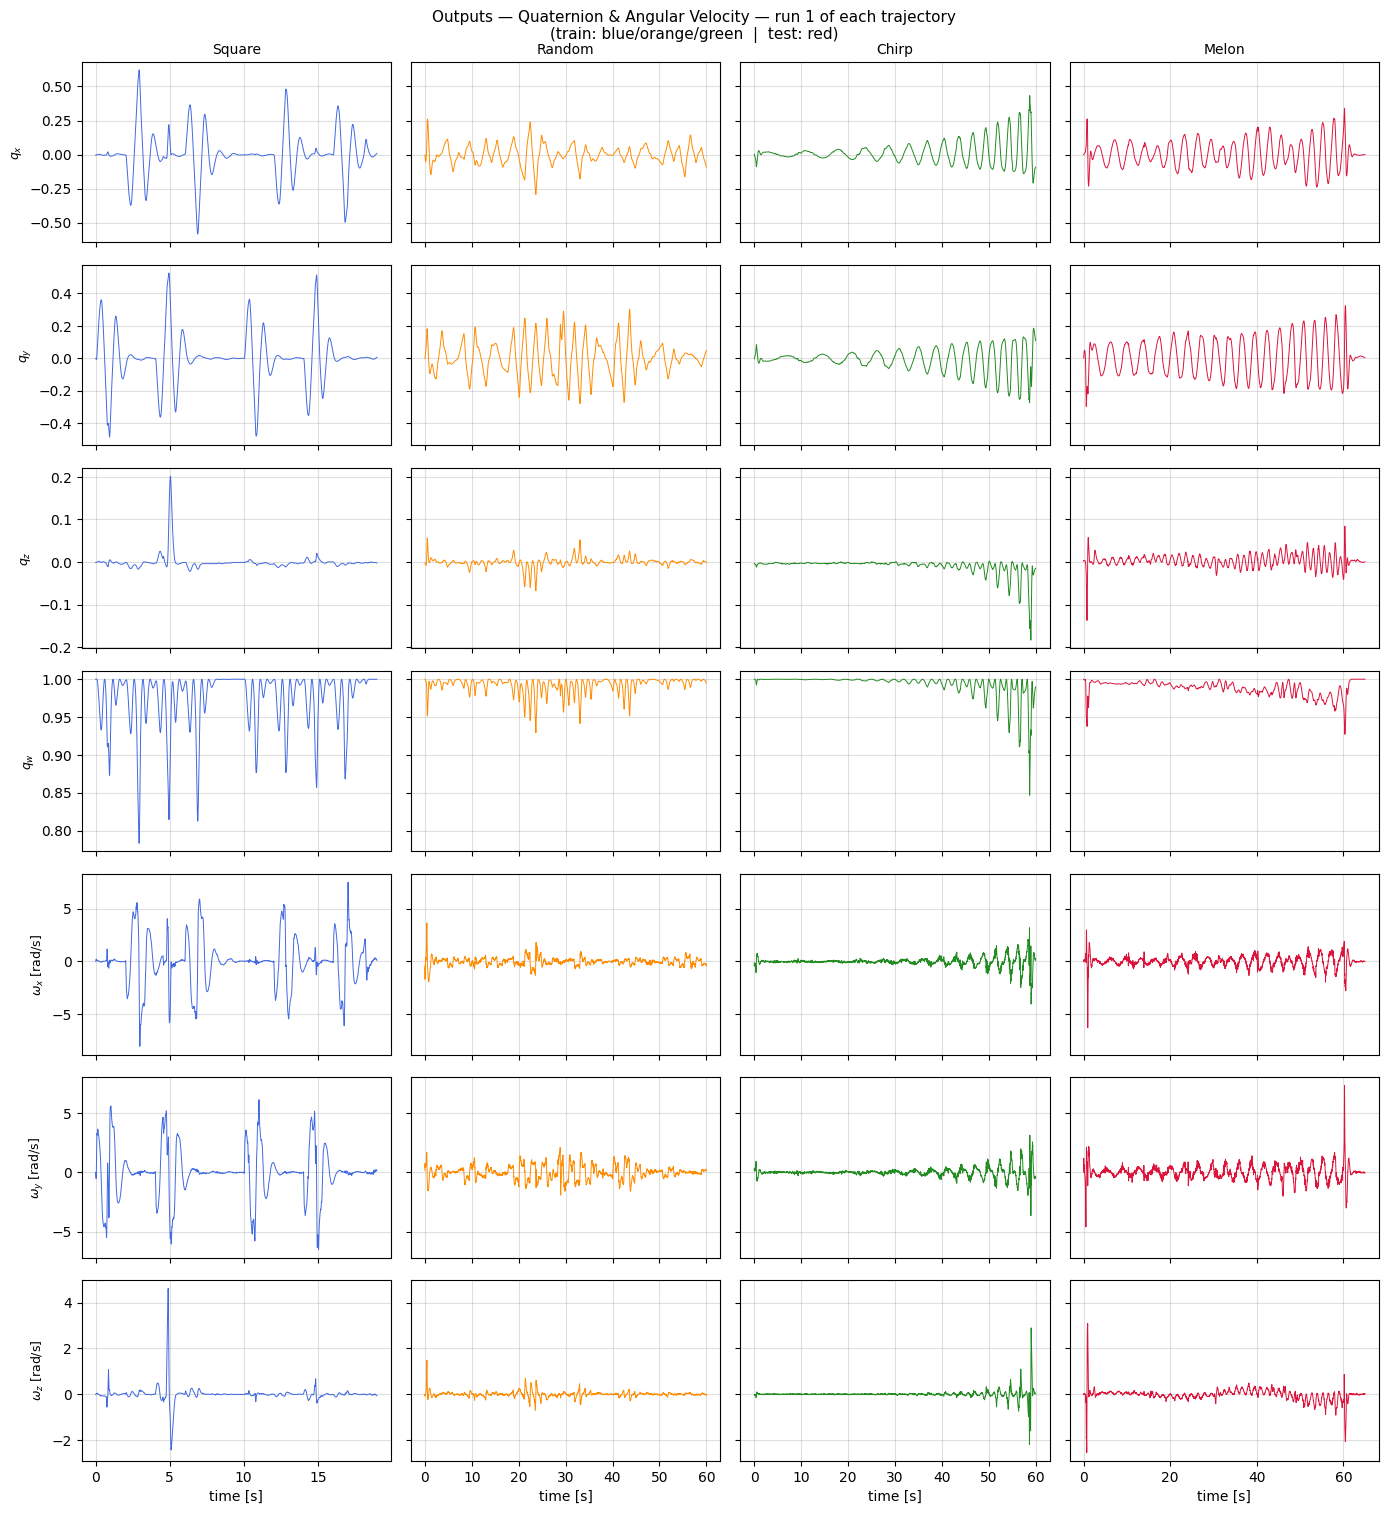

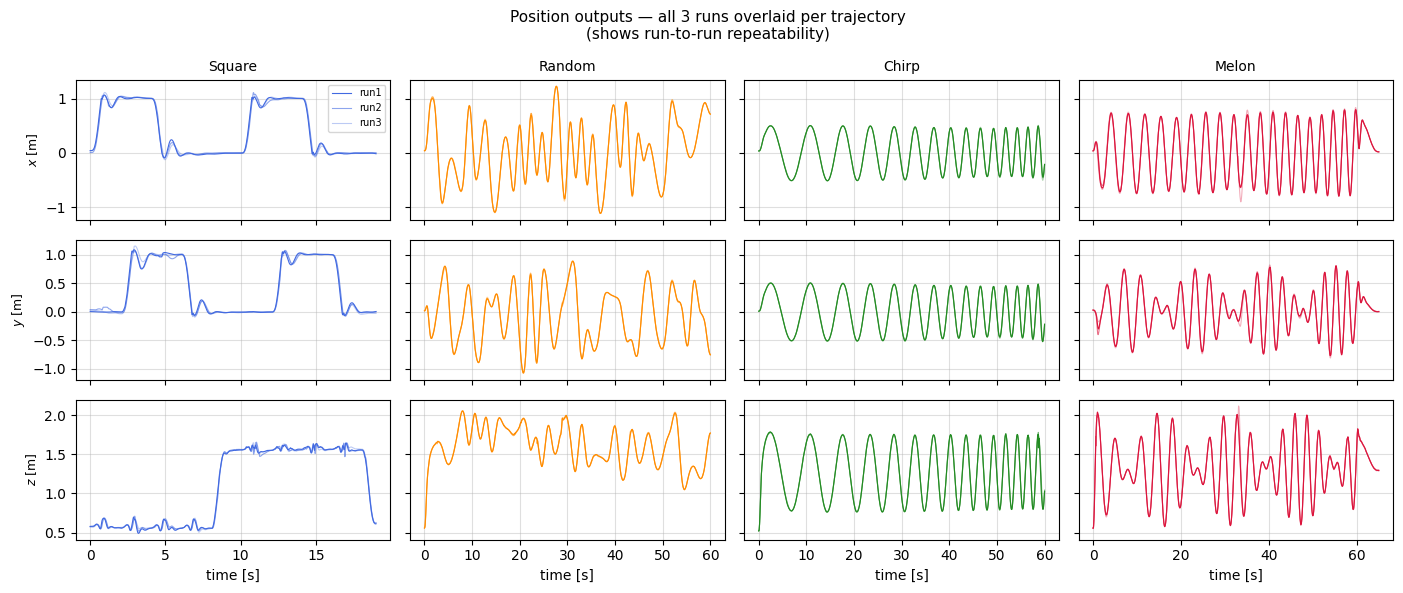

In [3]:
data_train, data_test = nlb.NanoDrone()

# train is a list of 9 Input_output_data (square/random/chirp x 3 runs)
# test  is a list of 3 Input_output_data (melon x 3 runs)

# train: 9 datasets  (square/random/chirp x run1/run2/run3)
# test:  3 datasets  (melon x run1/run2/run3)

sampling_time = data_train[0].sampling_time  # 0.01 s

# ── Signal definitions ─────────────────────────────────────────────────────
input_labels  = ['$m_1$ [rad/s]', '$m_2$ [rad/s]', '$m_3$ [rad/s]', '$m_4$ [rad/s]']
output_labels = ['$x$ [m]', '$y$ [m]', '$z$ [m]',
                 '$v_x$ [m/s]', '$v_y$ [m/s]', '$v_z$ [m/s]',
                 '$q_x$', '$q_y$', '$q_z$', '$q_w$',
                 '$\omega_x$ [rad/s]', '$\omega_y$ [rad/s]', '$\omega_z$ [rad/s]']

train_trajectories = ['square', 'random', 'chirp']
test_trajectories  = ['melon']

# Build lookup: name -> dataset
data_dict = {d.name: d for d in data_train + data_test}

# ── Figure 1: Inputs (motor speeds) ────────────────────────────────────────
# Show run1 of each trajectory (train + test), one row per motor
all_trajectories = train_trajectories + test_trajectories
colors = {'square': 'royalblue',
          'random': 'darkorange',
          'chirp':  'forestgreen',
          'melon':  'crimson'}

nu = 4
fig1, axes1 = plt.subplots(nu, len(all_trajectories),
                           figsize=(14, 7), sharex='col', sharey='row')
fig1.suptitle('Motor inputs — run 1 of each trajectory\n'
              '(train: blue/orange/green  |  test: red)', fontsize=11)

for col_idx, traj in enumerate(all_trajectories):
    split  = 'test' if traj == 'melon' else 'train'
    key    = f'{split} {traj} run1'
    d      = data_dict[key]
    t      = np.arange(len(d.u)) * sampling_time
    color  = colors[traj]
    axes1[0, col_idx].set_title(traj.capitalize(), fontsize=10)
    for row_idx in range(nu):
        axes1[row_idx, col_idx].plot(t, d.u[:, row_idx], color=color, lw=0.7)
        axes1[row_idx, col_idx].grid(True, alpha=0.4)
    axes1[-1, col_idx].set_xlabel('time [s]')

for row_idx, lbl in enumerate(input_labels):
    axes1[row_idx, 0].set_ylabel(lbl, fontsize=9)

plt.tight_layout()
# plt.savefig('../figures/NanoDrone_inputs.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 2: Outputs (state vector) ───────────────────────────────────────
# Show run1 of each trajectory, one row per output channel
# Split into two figures to keep it readable (position+velocity | attitude)
output_groups = {
    'Position & Velocity': (range(6),  output_labels[:6]),
    'Quaternion & Angular Velocity': (range(6, 13), output_labels[6:]),
}

for group_name, (out_idx, out_lbls) in output_groups.items():
    out_idx = list(out_idx)
    ny_group = len(out_idx)
    fig, axes = plt.subplots(ny_group, len(all_trajectories),
                             figsize=(14, 2.2 * ny_group),
                             sharex='col', sharey='row')
    fig.suptitle(f'Outputs — {group_name} — run 1 of each trajectory\n'
                 f'(train: blue/orange/green  |  test: red)', fontsize=11)

    for col_idx, traj in enumerate(all_trajectories):
        split = 'test' if traj == 'melon' else 'train'
        key   = f'{split} {traj} run1'
        d     = data_dict[key]
        t     = np.arange(len(d.y)) * sampling_time
        color = colors[traj]
        axes[0, col_idx].set_title(traj.capitalize(), fontsize=10)
        for row_idx, oi in enumerate(out_idx):
            axes[row_idx, col_idx].plot(t, d.y[:, oi], color=color, lw=0.7)
            axes[row_idx, col_idx].grid(True, alpha=0.4)
        axes[-1, col_idx].set_xlabel('time [s]')

    for row_idx, lbl in enumerate(out_lbls):
        axes[row_idx, 0].set_ylabel(lbl, fontsize=9)

    plt.tight_layout()
    safe_name = group_name.replace(' ', '_').replace('&', 'and')
    # plt.savefig(f'../figures/NanoDrone_{safe_name}.jpg', dpi=300, bbox_inches='tight')
    plt.show()

# ── Figure 3: All 3 runs overlaid per trajectory (position only) ───────────
# Shows repeatability across runs
fig3, axes3 = plt.subplots(3, len(all_trajectories),
                            figsize=(14, 6), sharex='col', sharey='row')
fig3.suptitle('Position outputs — all 3 runs overlaid per trajectory\n'
              '(shows run-to-run repeatability)', fontsize=11)

run_alphas = [1.0, 0.6, 0.35]
for col_idx, traj in enumerate(all_trajectories):
    split = 'test' if traj == 'melon' else 'train'
    color = colors[traj]
    axes3[0, col_idx].set_title(traj.capitalize(), fontsize=10)
    for run in [1, 2, 3]:
        key = f'{split} {traj} run{run}'
        d   = data_dict[key]
        t   = np.arange(len(d.y)) * sampling_time
        for row_idx, oi in enumerate([0, 1, 2]):  # x, y, z
            axes3[row_idx, col_idx].plot(t, d.y[:, oi],
                                         color=color,
                                         alpha=run_alphas[run - 1],
                                         lw=0.8,
                                         label=f'run{run}')
        axes3[-1, col_idx].set_xlabel('time [s]')

for row_idx, lbl in enumerate(['$x$ [m]', '$y$ [m]', '$z$ [m]']):
    axes3[row_idx, 0].set_ylabel(lbl, fontsize=9)

axes3[0, 0].legend(fontsize=7, loc='upper right')
for ax in axes3.flat:
    ax.grid(True, alpha=0.4)

plt.tight_layout()
# plt.savefig('../figures/NanoDrone_repeatability.jpg', dpi=300, bbox_inches='tight')
plt.show()